<a href="https://colab.research.google.com/github/priyanka22wh1a1264/DataAnalysis/blob/main/logisticregression(cancer).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic Regression

#cancer patient prediction

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.datasets import load_breast_cancer

In [2]:
#data preparation
data=load_breast_cancer()
data.keys()
df=pd.DataFrame(data['data'],columns=data['feature_names'])
df["Cancer"]=data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Cancer
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<Axes: xlabel='Cancer', ylabel='Count'>

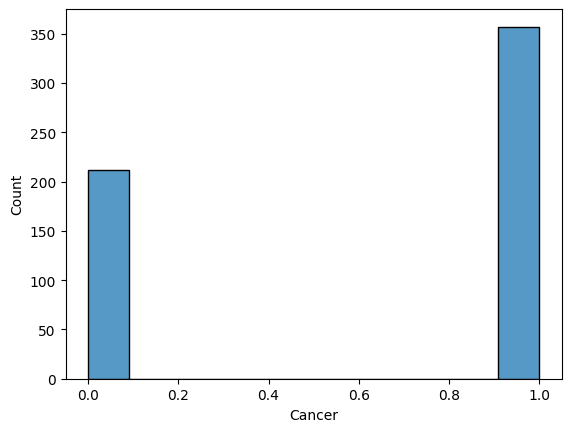

In [3]:
sns.histplot(x="Cancer",data=df)

The number of cancer cases is higher than non-cancer cases in the dataset.

<Axes: xlabel='mean radius', ylabel='Count'>

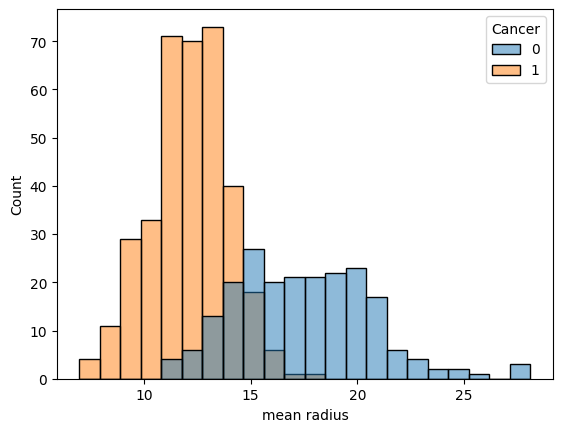

In [4]:
sns.histplot(x="mean radius",data=df,hue="Cancer")

Cancer cases mostly have smaller mean radius values, generally between 8 and 15.

Non-cancer cases mostly have larger mean radius values, mainly between 14 and 22.

#model training

In [5]:
#divide data into i/p and o/p
x=df.drop("Cancer",axis=1)
y=df["Cancer"]
y

,Cancer
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [6]:
#split data into training and testing data
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [7]:
#model training

model=LogisticRegression()
model.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [8]:
ypred=model.predict(xtest)
ypred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1])

#Performance Metrics

In [9]:
confusion_matrix(ytest,ypred)

array([[ 59,   4],
       [  1, 107]])

In [10]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



The model has an overall accuracy of 97%, meaning it correctly predicts most cases.

The model detects cancer cases very effectively, since recall for cancer is very high (0.99).

In [11]:
print("training eff",model.score(xtrain,ytrain))
print("testing eff",model.score(xtest,ytest))

training eff 0.9346733668341709
testing eff 0.9707602339181286


the model can be considered a generalized model because it performs well on both training and unseen test data.

In [12]:
#new input
newdata=df.iloc[:1,:-1]
pred=model.predict(newdata)
prob=model.predict_proba(newdata)
print(pred)

if pred==0:
  print("no sign of cancer ")
else:
  print("sign of cancer")
print("probability:" , prob)

[0]
no sign of cancer 
probability: [[1.00000000e+00 5.82333545e-14]]


In [13]:
newdata=df.iloc[[568],:-1]
pred=model.predict(newdata)
prob=model.predict_proba(newdata)
print(pred)

if pred==0:
  print("no sign of cancer ")
else:
  print("sign of cancer")
print("probability:" , prob)

[1]
sign of cancer
probability: [[0.02778926 0.97221074]]
